LBFGS step   10 | Total 1.048e+02 | Data 8.950e-04 | Phys 8.857e-02 | IC 1.736e-02
LBFGS step   20 | Total 3.589e+01 | Data 2.927e-04 | Phys 1.352e-01 | IC 6.537e-03
LBFGS step   30 | Total 6.802e+00 | Data 5.894e-05 | Phys 3.418e-02 | IC 8.179e-04
LBFGS step   40 | Total 1.806e+00 | Data 1.630e-05 | Phys 5.311e-03 | IC 2.838e-04
LBFGS step   50 | Total 8.363e-01 | Data 7.771e-06 | Phys 2.243e-03 | IC 1.751e-04
LBFGS step   60 | Total 4.883e-01 | Data 4.580e-06 | Phys 1.548e-03 | IC 1.083e-04
LBFGS step   70 | Total 3.111e-01 | Data 2.971e-06 | Phys 1.114e-03 | IC 8.333e-05
LBFGS step   80 | Total 2.193e-01 | Data 2.117e-06 | Phys 8.918e-04 | IC 6.457e-05
LBFGS step   90 | Total 1.642e-01 | Data 1.577e-06 | Phys 7.538e-04 | IC 5.319e-05
LBFGS step  100 | Total 1.236e-01 | Data 1.181e-06 | Phys 5.571e-04 | IC 4.416e-05
LBFGS step  110 | Total 9.918e-02 | Data 9.612e-07 | Phys 5.177e-04 | IC 3.899e-05
LBFGS step  120 | Total 8.292e-02 | Data 7.998e-07 | Phys 4.761e-04 | IC 3.539e-05
LBFG

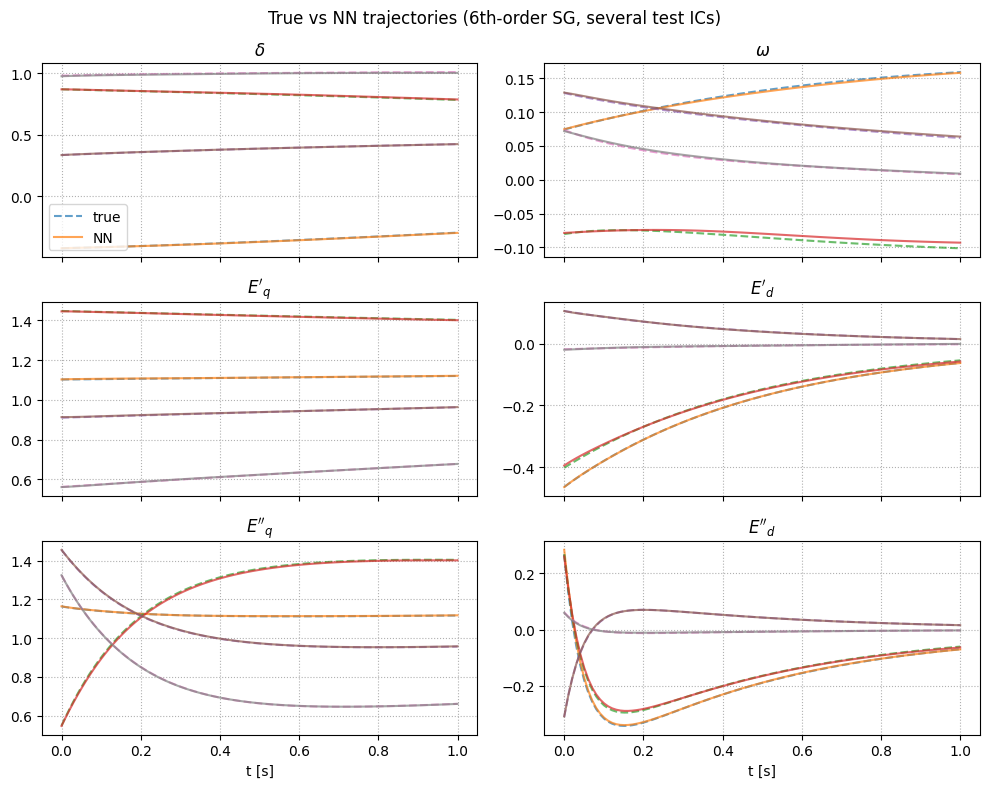

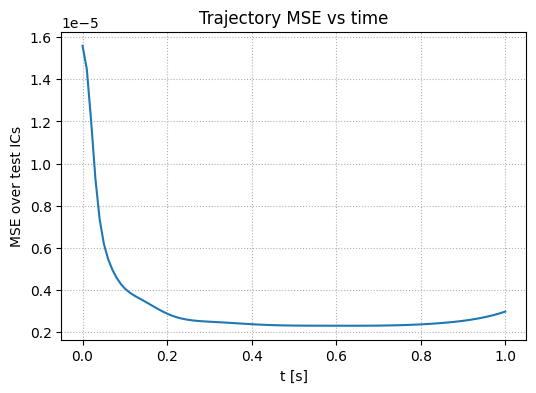

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchdiffeq import odeint
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1. Configuration
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32
torch.manual_seed(0)

# State ranges (for sampling ICs and collocation)
delta_range  = (-1.0, 1.0)   # δ
omega_range  = (-0.2, 0.2)   # ω
Eq_p_range   = (0.5, 1.5)    # Eq'
Ed_p_range   = (-0.5, 0.5)   # Ed'
Eq_pp_range  = (0.5, 1.5)    # Eq''
Ed_pp_range  = (-0.5, 0.5)   # Ed''

t_min, t_max = 0.0, 1.0

# Training hyperparameters
N_IC_train      = 64
N_t_steps_train = 50
N_coll_train    = 512
N_IC_IC_loss    = 128
batch_size_data = 256          # not used in LBFGS (we use full batch)
n_epochs        = 10000        # not used in LBFGS
lr              = 1e-4         # not used in LBFGS

lambda_data = 10e4
lambda_phys = 1.0
lambda_ic   = 10.0

# Test settings
N_IC_test      = 16
N_t_steps_test = 100
N_coll_test    = 2000

# ============================================================
# 2. Helper sampling functions
# ============================================================

def sample_initial_conditions(n_ic):
    δ0     = torch.empty(n_ic, 1).uniform_(*delta_range)
    ω0     = torch.empty(n_ic, 1).uniform_(*omega_range)
    Eq0_p  = torch.empty(n_ic, 1).uniform_(*Eq_p_range)
    Ed0_p  = torch.empty(n_ic, 1).uniform_(*Ed_p_range)
    Eq0_pp = torch.empty(n_ic, 1).uniform_(*Eq_pp_range)
    Ed0_pp = torch.empty(n_ic, 1).uniform_(*Ed_pp_range)
    x0 = torch.cat([δ0, ω0, Eq0_p, Ed0_p, Eq0_pp, Ed0_pp], dim=-1)
    return x0

def sample_times(n_t):
    return torch.empty(n_t, 1).uniform_(t_min, t_max)

# ============================================================
# 3. 6D Synchronous Generator ODE model (toy but structured)
# ============================================================

class SynGen6D(nn.Module):
    """
    x = [δ, ω, Eq', Ed', Eq'', Ed'']

    dδ/dt    = ω
    dω/dt    = (P_m - P_e(δ, Eq'', Ed'')) / (2H) - D*ω
    dEq'/dt  = (E_f - Eq') / Tdo'
    dEd'/dt  = -Ed' / Tqo'
    dEq''/dt = (Eq' - Eq'') / Tdo''
    dEd''/dt = (Ed' - Ed'') / Tqo''

    P_e ≈ |E''| V / X * sin(δ), |E''| = sqrt(Eq''^2 + Ed''^2)
    """

    def __init__(self,
                 H=3.5,
                 D=1.0,
                 P_m=0.8,
                 E_f=1.2,
                 V=1.0,
                 X=0.6,
                 Tdo_prime=5.0,
                 Tqo_prime=0.5,
                 Tdo_dprime=0.2,
                 Tqo_dprime=0.05):
        super().__init__()
        self.H           = H
        self.D           = D
        self.P_m         = P_m
        self.E_f         = E_f
        self.V           = V
        self.X           = X
        self.Tdo_prime   = Tdo_prime
        self.Tqo_prime   = Tqo_prime
        self.Tdo_dprime  = Tdo_dprime
        self.Tqo_dprime  = Tqo_dprime

    def forward(self, t, x):
        δ     = x[..., 0]
        ω     = x[..., 1]
        Eq_p  = x[..., 2]
        Ed_p  = x[..., 3]
        Eq_pp = x[..., 4]
        Ed_pp = x[..., 5]

        E_mag_pp = torch.sqrt(Eq_pp**2 + Ed_pp**2 + 1e-9)
        P_e = (E_mag_pp * self.V / self.X) * torch.sin(δ)

        dδ_dt     = ω
        dω_dt     = (self.P_m - P_e) / (2 * self.H) - self.D * ω
        dEq_p_dt  = (self.E_f - Eq_p) / self.Tdo_prime
        dEd_p_dt  = -Ed_p / self.Tqo_prime
        dEq_pp_dt = (Eq_p - Eq_pp) / self.Tdo_dprime
        dEd_pp_dt = (Ed_p - Ed_pp) / self.Tqo_dprime

        dxdt = torch.stack(
            [dδ_dt, dω_dt, dEq_p_dt, dEd_p_dt, dEq_pp_dt, dEd_pp_dt],
            dim=-1
        )
        return dxdt

# ============================================================
# 4. Solution network: NORMAL MLP (t, x0) -> x_hat(t; x0)
#    (same training/losses as your original script)
# ============================================================

class SolutionNetMLP(nn.Module):
    """
    Normal MLP mapping (t, x0) -> x_hat.
    We keep the useful periodic feature trick for δ0 by using cos/sin(δ0).

    Input features:
      [t, cos(δ0), sin(δ0), ω0, Eq0', Ed0', Eq0'', Ed0'']  -> 8 dims
    Output:
      x_hat in R^6
    """
    def __init__(self, hidden=128, n_hidden=4, activation=nn.Tanh):
        super().__init__()
        in_dim = 8
        layers = []
        dim = in_dim
        for _ in range(n_hidden):
            layers.append(nn.Linear(dim, hidden))
            layers.append(activation())
            dim = hidden
        layers.append(nn.Linear(dim, 6))
        self.net = nn.Sequential(*layers)

    def forward(self, t, x0):
        """
        t:  (N, 1)
        x0: (N, 6)
        """
        δ0     = x0[:, 0:1]
        ω0     = x0[:, 1:2]
        Eq0_p  = x0[:, 2:3]
        Ed0_p  = x0[:, 3:4]
        Eq0_pp = x0[:, 4:5]
        Ed0_pp = x0[:, 5:6]

        cosδ0 = torch.cos(δ0)
        sinδ0 = torch.sin(δ0)

        z = torch.cat([t, cosδ0, sinδ0, ω0, Eq0_p, Ed0_p, Eq0_pp, Ed0_pp], dim=-1)
        return self.net(z)

# ============================================================
# 5. Generate trajectories for supervised data loss
# ============================================================

def generate_trajectories(ode_model,
                          n_ic=N_IC_train,
                          n_t_steps=N_t_steps_train):
    x0_all = sample_initial_conditions(n_ic).to(device=device, dtype=dtype)
    t_grid = torch.linspace(t_min, t_max, n_t_steps,
                            device=device, dtype=dtype)

    traj_list = []
    with torch.no_grad():
        for i in range(n_ic):
            x0 = x0_all[i:i+1]
            sol = odeint(ode_model, x0, t_grid)  # (T,1,6)
            traj_list.append(sol[:, 0, :])
    traj = torch.stack(traj_list, dim=0)  # (n_ic, T, 6)
    return x0_all, t_grid, traj

def build_data_pairs(x0_all, t_grid, traj):
    n_ic, n_t_steps, _ = traj.shape

    ic_idx = torch.arange(n_ic).view(-1, 1).repeat(1, n_t_steps)
    t_idx  = torch.arange(n_t_steps).view(1, -1).repeat(n_ic, 1)

    ic_idx = ic_idx.reshape(-1)
    t_idx  = t_idx.reshape(-1)

    x0_pairs = x0_all[ic_idx]
    t_pairs  = t_grid[t_idx].unsqueeze(-1)
    x_pairs  = traj[ic_idx, t_idx, :]

    return t_pairs, x0_pairs, x_pairs

# ============================================================
# 6. Physics residual and IC loss
# ============================================================

def sample_collocation_points(n_coll):
    t_c  = sample_times(n_coll)
    x0_c = sample_initial_conditions(n_coll)
    return t_c.to(device), x0_c.to(device)

def physics_residual(solution_net, ode_model, t_c, x0_c, create_graph=True):
    """
    Compute residual = d/dt x_hat(t,x0) - f(t, x_hat).
    Safe to call even under torch.no_grad(); we re-enable grad internally.
    """
    x0_c = x0_c.to(device)

    with torch.enable_grad():
        t_c = t_c.clone().detach().to(device).requires_grad_(True)

        x_hat = solution_net(t_c, x0_c)  # (N, 6)

        # ∂x_hat/∂t
        dxdt_hat_list = []
        for i in range(6):
            grad_i = torch.autograd.grad(
                x_hat[:, i].sum(),
                t_c,
                create_graph=create_graph,
                retain_graph=True,
            )[0]
            dxdt_hat_list.append(grad_i)
        dxdt_hat = torch.cat(dxdt_hat_list, dim=-1)  # (N,6)

        dxdt_phys = ode_model(t_c.squeeze(-1), x_hat)  # (N,6)
        residual = dxdt_hat - dxdt_phys

    if not create_graph:
        residual = residual.detach()

    return residual

def ic_loss(solution_net, n_ic_ic=N_IC_IC_loss):
    x0 = sample_initial_conditions(n_ic_ic).to(device)
    t0 = torch.zeros(x0.shape[0], 1, device=device, dtype=dtype)
    x_hat0 = solution_net(t0, x0)
    return torch.mean((x_hat0 - x0) ** 2)

# ============================================================
# 7. Training with LBFGS + line search
# ============================================================

def train_lbfgs():
    ode_model    = SynGen6D().to(device)
    solution_net = SolutionNetMLP(hidden=128, n_hidden=4).to(device)

    # ----- precompute supervised trajectories -----
    x0_all, t_grid, traj = generate_trajectories(ode_model)
    x0_all = x0_all.to(device)
    t_grid = t_grid.to(device)
    traj   = traj.to(device)

    t_pairs, x0_pairs, x_pairs = build_data_pairs(x0_all, t_grid, traj)
    t_pairs  = t_pairs.to(device)
    x0_pairs = x0_pairs.to(device)
    x_pairs  = x_pairs.to(device)

    # Use full batch for LBFGS
    t_data  = t_pairs
    x0_data = x0_pairs
    x_data  = x_pairs

    # Fixed collocation set for the LBFGS phase
    t_c, x0_c = sample_collocation_points(N_coll_train)
    t_c  = t_c.to(device)
    x0_c = x0_c.to(device)

    # Fixed IC set for IC loss
    x0_ic = sample_initial_conditions(N_IC_IC_loss).to(device)
    t0_ic = torch.zeros(x0_ic.shape[0], 1, device=device, dtype=dtype)

    optimizer = optim.LBFGS(
        solution_net.parameters(),
        lr=1.0,
        max_iter=20,                 # max line-search iterations per .step()
        history_size=100,
        line_search_fn="strong_wolfe"  # line search ON
    )

    # Number of outer LBFGS steps
    n_outer_steps = 200

    def closure():
        optimizer.zero_grad()

        # ----- data loss (full batch) -----
        x_pred    = solution_net(t_data, x0_data)
        data_loss = torch.mean((x_pred - x_data) ** 2)

        # ----- physics residual on fixed collocation -----
        residual  = physics_residual(solution_net, ode_model,
                                     t_c, x0_c,
                                     create_graph=True)
        phys_loss = torch.mean(residual ** 2)

        # ----- IC loss on fixed ICs -----
        x_hat0 = solution_net(t0_ic, x0_ic)
        ic_l   = torch.mean((x_hat0 - x0_ic) ** 2)

        loss = lambda_data * data_loss + lambda_phys * phys_loss + lambda_ic * ic_l
        loss.backward()
        return loss

    for step in range(1, n_outer_steps + 1):
        loss = optimizer.step(closure)

        if step % 10 == 0:
            with torch.no_grad():
                x_pred    = solution_net(t_data, x0_data)
                data_loss = torch.mean((x_pred - x_data) ** 2)

                x_hat0 = solution_net(t0_ic, x0_ic)
                ic_l   = torch.mean((x_hat0 - x0_ic) ** 2)

            residual = physics_residual(solution_net, ode_model,
                                        t_c, x0_c,
                                        create_graph=False)
            with torch.no_grad():
                phys_loss = torch.mean(residual ** 2)

            print(f"LBFGS step {step:4d} | "
                  f"Loss {loss.item():.3e} | "
                  f"Data {data_loss.item():.3e} | "
                  f"Phys {phys_loss.item():.3e} | "
                  f"IC {ic_l.item():.3e}")

    return ode_model, solution_net

# ============================================================
# 8. Evaluation on test ICs and plotting
# ============================================================

def evaluate_and_plot(ode_model, solution_net):
    solution_net.eval()
    ode_model.eval()

    x0_test = sample_initial_conditions(N_IC_test).to(device)
    t_test  = torch.linspace(t_min, t_max, N_t_steps_test,
                             device=device, dtype=dtype)

    # True trajectories
    traj_true = []
    with torch.no_grad():
        for i in range(N_IC_test):
            x0  = x0_test[i:i+1]
            sol = odeint(ode_model, x0, t_test)  # (T,1,6)
            traj_true.append(sol[:, 0, :])
    traj_true = torch.stack(traj_true, dim=0)  # (N,T,6)

    # NN trajectories
    with torch.no_grad():
        T      = t_test.shape[0]
        t_rep  = t_test.unsqueeze(0).repeat(N_IC_test, 1)   # (N,T)
        x0_rep = x0_test.unsqueeze(1).repeat(1, T, 1)       # (N,T,6)

        t_flat   = t_rep.reshape(-1, 1)
        x0_flat  = x0_rep.reshape(-1, 6)
        x_hat    = solution_net(t_flat, x0_flat)
        traj_hat = x_hat.reshape(N_IC_test, T, 6)

    # Errors
    with torch.no_grad():
        err         = traj_hat - traj_true
        mse_per_t   = torch.mean(err ** 2, dim=(0, 2))
        mse_per_ic  = torch.mean(err ** 2, dim=(1, 2))
        mse_global  = torch.mean(err ** 2).item()
        print(f"Global test MSE over trajectories: {mse_global:.3e}")

    # To numpy
    t_test_np    = t_test.cpu().numpy()
    traj_true_np = traj_true.cpu().numpy()
    traj_hat_np  = traj_hat.cpu().numpy()
    mse_per_t_np = mse_per_t.cpu().numpy()

    # Plot 1: example trajectories (first few ICs, all 6 states)
    n_plot = min(4, N_IC_test)
    fig1, axes1 = plt.subplots(3, 2, figsize=(10, 8), sharex=True)
    axes1 = axes1.ravel()
    state_labels = [r"$\delta$", r"$\omega$", r"$E'_q$", r"$E'_d$",
                    r"$E''_q$", r"$E''_d$"]

    for s in range(6):
        ax = axes1[s]
        for i in range(n_plot):
            ax.plot(t_test_np,
                    traj_true_np[i, :, s],
                    linestyle='--', alpha=0.7,
                    label="true" if i == 0 else None)
            ax.plot(t_test_np,
                    traj_hat_np[i, :, s],
                    linestyle='-', alpha=0.7,
                    label="NN" if i == 0 else None)
        ax.set_title(state_labels[s])
        ax.grid(True, linestyle=':')
        if s >= 4:
            ax.set_xlabel("t [s]")
        if s == 0:
            ax.legend()
    fig1.suptitle("True vs NN trajectories (6th-order SG, several test ICs)")
    fig1.tight_layout()

    # Plot 2: MSE vs time
    fig2, ax2 = plt.subplots(figsize=(6, 4))
    ax2.plot(t_test_np, mse_per_t_np)
    ax2.set_xlabel("t [s]")
    ax2.set_ylabel("MSE over test ICs")
    ax2.set_title("Trajectory MSE vs time")
    ax2.grid(True, linestyle=':')

    plt.show()

# ============================================================
# 9. Main
# ============================================================

if __name__ == "__main__":
    ode_model, solution_net = train_lbfgs()
    evaluate_and_plot(ode_model, solution_net)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchdiffeq import odeint
import matplotlib.pyplot as plt

# ============================================================
# 1. Configuration (Swing equation)
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32
torch.manual_seed(0)

# Swing state ranges (sampling ICs / collocation)
delta_range = (-1.5, 1.5)   # rad
omega_range = (-1.0, 1.0)   # pu speed deviation (or rad/s scaled)

t_min, t_max = 0.0, 2.0

# Training hyperparameters (LBFGS, full batch)
N_IC_train      = 64
N_t_steps_train = 80
N_coll_train    = 1024
N_IC_IC_loss    = 256

lambda_data = 1e4
lambda_phys = 1.0
lambda_ic   = 10.0

# Test settings
N_IC_test      = 16
N_t_steps_test = 200

# ============================================================
# 2. Helper sampling
# ============================================================

def sample_initial_conditions(n_ic):
    δ0 = torch.empty(n_ic, 1).uniform_(*delta_range)
    ω0 = torch.empty(n_ic, 1).uniform_(*omega_range)
    return torch.cat([δ0, ω0], dim=-1)

def sample_times(n_t):
    return torch.empty(n_t, 1).uniform_(t_min, t_max)

# ============================================================
# 3. Swing ODE model (SMIB-style)
# ============================================================

class SwingODE(nn.Module):
    """
    x = [δ, ω]
    dδ/dt = ω
    dω/dt = (P_m - P_e(δ) - D*ω)/(2H)

    P_e(δ) = P_max * sin(δ)
    """
    def __init__(self, H=3.5, D=1.0, P_m=0.8, P_max=1.0):
        super().__init__()
        self.H = H
        self.D = D
        self.P_m = P_m
        self.P_max = P_max

    def forward(self, t, x):
        δ = x[..., 0]
        ω = x[..., 1]
        P_e = self.P_max * torch.sin(δ)

        dδ = ω
        dω = (self.P_m - P_e - self.D * ω) / (2.0 * self.H)
        return torch.stack([dδ, dω], dim=-1)

# ============================================================
# 4. Normal MLP solution net: (t, x0) -> x_hat(t; x0)
# ============================================================

class SolutionNetSwingMLP(nn.Module):
    """
    Normal MLP mapping (t, x0) -> x_hat (δ, ω).
    Use cos/sin feature for δ0.
    Input: [t, cos(δ0), sin(δ0), ω0] -> 4 dims
    Output: [δ_hat, ω_hat] -> 2 dims
    """
    def __init__(self, hidden=128, n_hidden=4, activation=nn.Tanh):
        super().__init__()
        in_dim = 4
        layers = []
        dim = in_dim
        for _ in range(n_hidden):
            layers += [nn.Linear(dim, hidden), activation()]
            dim = hidden
        layers.append(nn.Linear(dim, 2))
        self.net = nn.Sequential(*layers)

    def forward(self, t, x0):
        δ0 = x0[:, 0:1]
        ω0 = x0[:, 1:2]
        z = torch.cat([t, torch.cos(δ0), torch.sin(δ0), ω0], dim=-1)
        return self.net(z)

# ============================================================
# 5. Generate trajectories for supervised data loss
# ============================================================

def generate_trajectories(ode_model, n_ic=N_IC_train, n_t_steps=N_t_steps_train):
    x0_all = sample_initial_conditions(n_ic).to(device=device, dtype=dtype)
    t_grid = torch.linspace(t_min, t_max, n_t_steps, device=device, dtype=dtype)

    traj_list = []
    with torch.no_grad():
        for i in range(n_ic):
            x0 = x0_all[i:i+1]
            sol = odeint(ode_model, x0, t_grid)  # (T,1,2)
            traj_list.append(sol[:, 0, :])
    traj = torch.stack(traj_list, dim=0)  # (n_ic, T, 2)
    return x0_all, t_grid, traj

def build_data_pairs(x0_all, t_grid, traj):
    n_ic, n_t_steps, _ = traj.shape
    ic_idx = torch.arange(n_ic).view(-1, 1).repeat(1, n_t_steps).reshape(-1)
    t_idx  = torch.arange(n_t_steps).view(1, -1).repeat(n_ic, 1).reshape(-1)

    x0_pairs = x0_all[ic_idx]
    t_pairs  = t_grid[t_idx].unsqueeze(-1)
    x_pairs  = traj[ic_idx, t_idx, :]
    return t_pairs, x0_pairs, x_pairs

# ============================================================
# 6. Physics residual and IC loss
# ============================================================

def sample_collocation_points(n_coll):
    t_c  = sample_times(n_coll).to(device=device, dtype=dtype)
    x0_c = sample_initial_conditions(n_coll).to(device=device, dtype=dtype)
    return t_c, x0_c

def physics_residual(solution_net, ode_model, t_c, x0_c, create_graph=True):
    """
    residual = d/dt x_hat(t,x0) - f(t, x_hat)
    Safe even under torch.no_grad(); we re-enable grad internally.
    """
    with torch.enable_grad():
        t_c = t_c.clone().detach().requires_grad_(True)
        x_hat = solution_net(t_c, x0_c)  # (N,2)

        # ∂x_hat/∂t
        dxdt_hat_list = []
        for i in range(2):
            grad_i = torch.autograd.grad(
                x_hat[:, i].sum(),
                t_c,
                create_graph=create_graph,
                retain_graph=True,
            )[0]
            dxdt_hat_list.append(grad_i)
        dxdt_hat = torch.cat(dxdt_hat_list, dim=-1)  # (N,2)

        dxdt_phys = ode_model(t_c.squeeze(-1), x_hat)  # (N,2)
        residual = dxdt_hat - dxdt_phys

    if not create_graph:
        residual = residual.detach()
    return residual

def ic_loss(solution_net, n_ic_ic=N_IC_IC_loss):
    x0 = sample_initial_conditions(n_ic_ic).to(device=device, dtype=dtype)
    t0 = torch.zeros(x0.shape[0], 1, device=device, dtype=dtype)
    x_hat0 = solution_net(t0, x0)
    return torch.mean((x_hat0 - x0) ** 2)

# ============================================================
# 7. Training with LBFGS + strong wolfe line search
# ============================================================

def train_lbfgs():
    ode_model    = SwingODE().to(device)
    solution_net = SolutionNetSwingMLP(hidden=128, n_hidden=4).to(device)

    # ----- supervised trajectories -----
    x0_all, t_grid, traj = generate_trajectories(ode_model)
    t_pairs, x0_pairs, x_pairs = build_data_pairs(x0_all, t_grid, traj)

    t_data  = t_pairs.to(device)
    x0_data = x0_pairs.to(device)
    x_data  = x_pairs.to(device)

    # fixed collocation
    t_c, x0_c = sample_collocation_points(N_coll_train)

    # fixed IC set
    x0_ic = sample_initial_conditions(N_IC_IC_loss).to(device=device, dtype=dtype)
    t0_ic = torch.zeros(x0_ic.shape[0], 1, device=device, dtype=dtype)

    optimizer = optim.LBFGS(
        solution_net.parameters(),
        lr=1.0,
        max_iter=25,
        history_size=100,
        line_search_fn="strong_wolfe"
    )

    n_outer_steps = 200

    def closure():
        optimizer.zero_grad()

        # data loss
        x_pred = solution_net(t_data, x0_data)
        data_l = torch.mean((x_pred - x_data) ** 2)

        # physics loss
        res = physics_residual(solution_net, ode_model, t_c, x0_c, create_graph=True)
        phys_l = torch.mean(res ** 2)

        # IC loss
        x_hat0 = solution_net(t0_ic, x0_ic)
        ic_l = torch.mean((x_hat0 - x0_ic) ** 2)

        loss = lambda_data * data_l + lambda_phys * phys_l + lambda_ic * ic_l
        loss.backward()
        return loss

    for step in range(1, n_outer_steps + 1):
        loss = optimizer.step(closure)

        if step % 10 == 0:
            with torch.no_grad():
                x_pred = solution_net(t_data, x0_data)
                data_l = torch.mean((x_pred - x_data) ** 2)

                x_hat0 = solution_net(t0_ic, x0_ic)
                ic_l = torch.mean((x_hat0 - x0_ic) ** 2)

            res = physics_residual(solution_net, ode_model, t_c, x0_c, create_graph=False)
            with torch.no_grad():
                phys_l = torch.mean(res ** 2)

            print(f"LBFGS step {step:4d} | "
                  f"Total {loss.item():.3e} | "
                  f"Data {data_l.item():.3e} | "
                  f"Phys {phys_l.item():.3e} | "
                  f"IC {ic_l.item():.3e}")

    return ode_model, solution_net

# ============================================================
# 8. Evaluation + plots
# ============================================================

def evaluate_and_plot(ode_model, solution_net):
    solution_net.eval()
    ode_model.eval()

    x0_test = sample_initial_conditions(N_IC_test).to(device=device, dtype=dtype)
    t_test  = torch.linspace(t_min, t_max, N_t_steps_test, device=device, dtype=dtype)

    # True
    traj_true = []
    with torch.no_grad():
        for i in range(N_IC_test):
            sol = odeint(ode_model, x0_test[i:i+1], t_test)
            traj_true.append(sol[:, 0, :])
    traj_true = torch.stack(traj_true, dim=0)  # (N,T,2)

    # NN
    with torch.no_grad():
        T = t_test.shape[0]
        t_rep  = t_test.unsqueeze(0).repeat(N_IC_test, 1)      # (N,T)
        x0_rep = x0_test.unsqueeze(1).repeat(1, T, 1)          # (N,T,2)

        t_flat  = t_rep.reshape(-1, 1)
        x0_flat = x0_rep.reshape(-1, 2)

        x_hat = solution_net(t_flat, x0_flat)
        traj_hat = x_hat.reshape(N_IC_test, T, 2)

    # errors
    with torch.no_grad():
        err = traj_hat - traj_true
        mse_per_t  = torch.mean(err ** 2, dim=(0, 2))
        mse_global = torch.mean(err ** 2).item()
        print(f"Global test MSE over trajectories: {mse_global:.3e}")

    t_np = t_test.cpu().numpy()
    true_np = traj_true.cpu().numpy()
    hat_np  = traj_hat.cpu().numpy()
    mse_t_np = mse_per_t.cpu().numpy()

    # Plot: trajectories
    fig1, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
    labels = [r"$\delta$", r"$\omega$"]
    for s in range(2):
        ax = axes[s]
        for i in range(min(4, N_IC_test)):
            ax.plot(t_np, true_np[i, :, s], "--", alpha=0.7, label="true" if i == 0 else None)
            ax.plot(t_np, hat_np[i, :, s], "-",  alpha=0.7, label="NN" if i == 0 else None)
        ax.set_ylabel(labels[s])
        ax.grid(True, linestyle=":")
        if s == 0:
            ax.legend()
    axes[-1].set_xlabel("t [s]")
    fig1.suptitle("Swing equation: True vs NN trajectories (several test ICs)")
    fig1.tight_layout()

    # Plot: MSE vs time
    fig2, ax2 = plt.subplots(figsize=(6, 4))
    ax2.plot(t_np, mse_t_np)
    ax2.set_xlabel("t [s]")
    ax2.set_ylabel("MSE over test ICs")
    ax2.set_title("Swing equation: Trajectory MSE vs time")
    ax2.grid(True, linestyle=":")

    plt.show()

# ============================================================
# 9. Main
# ============================================================

if __name__ == "__main__":
    ode_model, solution_net = train_lbfgs()
    evaluate_and_plot(ode_model, solution_net)

LBFGS step   10 | Total 2.271e-01 | Data 1.794e-05 | Phys 1.815e-04 | IC 4.786e-05
LBFGS step   20 | Total 3.760e-02 | Data 3.177e-06 | Phys 4.146e-05 | IC 1.784e-05
LBFGS step   30 | Total 1.510e-02 | Data 1.406e-06 | Phys 2.606e-05 | IC 8.431e-06
LBFGS step   40 | Total 6.344e-03 | Data 5.759e-07 | Phys 1.362e-05 | IC 7.169e-06
LBFGS step   50 | Total 4.133e-03 | Data 3.992e-07 | Phys 1.162e-05 | IC 4.449e-06
LBFGS step   60 | Total 3.105e-03 | Data 3.049e-07 | Phys 9.752e-06 | IC 3.232e-06
LBFGS step   70 | Total 2.574e-03 | Data 2.510e-07 | Phys 8.571e-06 | IC 2.056e-06
LBFGS step   80 | Total 2.146e-03 | Data 2.062e-07 | Phys 7.183e-06 | IC 2.088e-06
LBFGS step   90 | Total 1.772e-03 | Data 1.692e-07 | Phys 5.473e-06 | IC 2.624e-06
LBFGS step  100 | Total 1.333e-03 | Data 1.280e-07 | Phys 4.591e-06 | IC 1.845e-06
LBFGS step  110 | Total 1.014e-03 | Data 9.809e-08 | Phys 4.391e-06 | IC 1.802e-06
LBFGS step  120 | Total 8.462e-04 | Data 8.152e-08 | Phys 3.905e-06 | IC 1.478e-06
LBFG